In [57]:
# Gerekli kütüphanelerin içe aktarılması
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.stats import poisson

In [58]:
# Gözlemlenen trafik verisi (1 dakikada geçen araç sayısı)
traffic_data = np.array([
12, 15, 10, 8, 14, 11, 13, 16, 9,
12, 11, 14, 10, 15
])

In [59]:
# Poisson dağılımı için negatif log-olabilirlik fonksiyonunu hesaplayan fonksiyon
def negative_log_likelihood(lam, data):

    # Lambda değerini çıkar
    lam = lam[0]

    # Negatif log-likelihood hesaplanması
    nll = -(np.sum(data * np.log(lam) - lam))

    return nll

In [60]:
# Lambda parametresi için başlangıç tahmini
initial_guess = [1.0]

# Negatif log-likelihood fonksiyonunu minimize ederek en iyi lambda değerini bulma
result = opt.minimize(
    negative_log_likelihood,
    initial_guess,
    args=(traffic_data,),
    bounds=[(0.001, None)]
)

# Tahmin edilen lambda değerini alma
lambda_mle = result.x[0]

# Sayısal ve analitik sonuçların yazdırılması
print("Sayısal Tahmin (MLE lambda):", lambda_mle)
print("Analitik Tahmin (Ortalama):", np.mean(traffic_data))

Sayısal Tahmin (MLE lambda): 12.142846011159076
Analitik Tahmin (Ortalama): 12.142857142857142


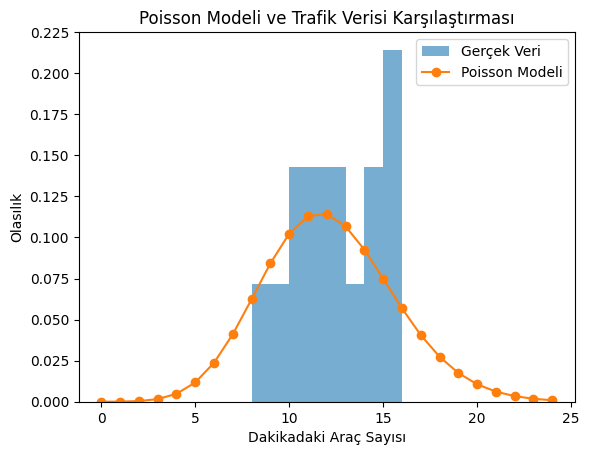

In [61]:

# Poisson PMF grafiği için değer aralığı oluşturma
x = np.arange(0, 25)

# Poisson olasılık değerlerinin hesaplanması
pmf = poisson.pmf(x, lambda_mle)

# Gerçek veri setinin histogramını çizme
plt.hist(traffic_data, bins=8, density=True, alpha=0.6, label="Gerçek Veri")

# Poisson modelinin grafiğini çizme
plt.plot(x, pmf, marker='o', label="Poisson Modeli")

# Grafik etiketleri ve başlık
plt.xlabel("Dakikadaki Araç Sayısı")
plt.ylabel("Olasılık")
plt.title("Poisson Modeli ve Trafik Verisi Karşılaştırması")
plt.legend()

plt.show()

In [62]:
# Veri setine aykırı bir değer (200 araç) eklenmesi
traffic_outlier = np.append(traffic_data, 200)

# Aykırı değer eklenmeden önce ve sonra ortalamanın karşılaştırılması
print("Aykırı değer olmadan ortalama:", np.mean(traffic_data))
print("Aykırı değer ile ortalama:", np.mean(traffic_outlier))

Aykırı değer olmadan ortalama: 12.142857142857142
Aykırı değer ile ortalama: 24.666666666666668
